This is trail in mapping two-moons dataset to a 2D gaussian data. This is by training a small neural network to predict the best parameters for mapping the function.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

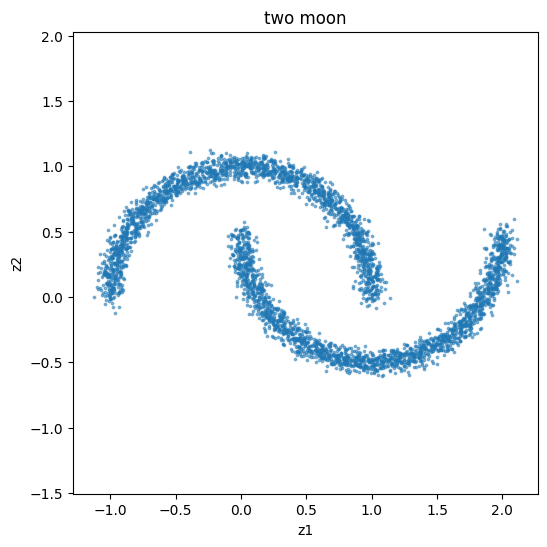

In [8]:
# Two-moons dataset (CONNECTED but bimodal-looking)
X, _ = make_moons(n_samples=4000, noise=0.05)
x_data = torch.tensor(X, dtype=torch.float32)

#plot 
p = x_data.detach().cpu().numpy()

plt.figure(figsize=(6,6))
plt.scatter(p[:,0], p[:,1], s=3, alpha=0.5)
plt.title("two moon")
plt.xlabel("z1")
plt.ylabel("z2")
plt.axis("equal")
plt.show()

In [9]:
base = torch.distributions.MultivariateNormal(
    torch.zeros(2), torch.eye(2)
)

In [10]:
class Coupling(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, z):
        z1 = z[:, 0:1]
        shift = self.net(z1)
        x2 = z[:, 1:2] + shift
        return torch.cat([z1, x2], dim=1)

    def inverse(self, x):
        x1 = x[:, 0:1]
        shift = self.net(x1)
        z2 = x[:, 1:2] - shift
        return torch.cat([x1, z2], dim=1)


In [11]:
class Rotation(nn.Module):
    def __init__(self, theta):
        super().__init__()
        self.theta = theta

    def forward(self, x):
        c, s = torch.cos(self.theta), torch.sin(self.theta)
        R = torch.tensor([[c, -s], [s, c]])
        return x @ R.T

    def inverse(self, x):
        c, s = torch.cos(self.theta), torch.sin(self.theta)
        R = torch.tensor([[c, s], [-s, c]])
        return x @ R.T


In [12]:
class Flow(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleList([
            Coupling(), Rotation(torch.tensor(0.6)),
            Coupling(), Rotation(torch.tensor(-0.6)),
            Coupling()
        ])

    def forward(self, z):
        for layer in self.layers:
            z = layer.forward(z)
        return z

    def inverse(self, x):
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x


In [13]:
def log_prob(flow, x):
    z = flow.inverse(x)
    return base.log_prob(z)

In [18]:
flow = Flow()
opt = optim.Adam(flow.parameters(), lr=1e-3)

for step in range(10000):
    opt.zero_grad()
    loss = -log_prob(flow, x_data).mean()
    loss.backward()
    opt.step()

    if step % 500 == 0:
        print(f"Step {step}, NLL: {loss.item():.3f}")


Step 0, NLL: 2.692
Step 500, NLL: 2.183
Step 1000, NLL: 2.156
Step 1500, NLL: 2.106
Step 2000, NLL: 2.070
Step 2500, NLL: 2.063
Step 3000, NLL: 2.059
Step 3500, NLL: 2.051
Step 4000, NLL: 2.040
Step 4500, NLL: 2.026
Step 5000, NLL: 2.020
Step 5500, NLL: 2.018
Step 6000, NLL: 2.016
Step 6500, NLL: 2.014
Step 7000, NLL: 2.013
Step 7500, NLL: 2.011
Step 8000, NLL: 2.009
Step 8500, NLL: 2.007
Step 9000, NLL: 2.006
Step 9500, NLL: 2.004


In [15]:
with torch.no_grad():
    z = base.sample((4000,))
    x_gen = flow.forward(z)

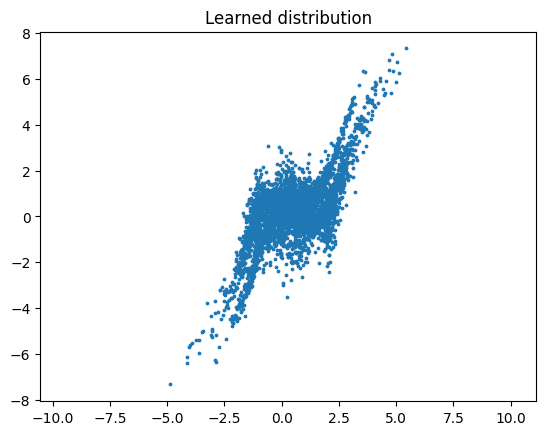

In [16]:
plt.scatter(x_gen[:,0], x_gen[:,1], s=3)
plt.title("Learned distribution")
plt.axis("equal")
plt.show()

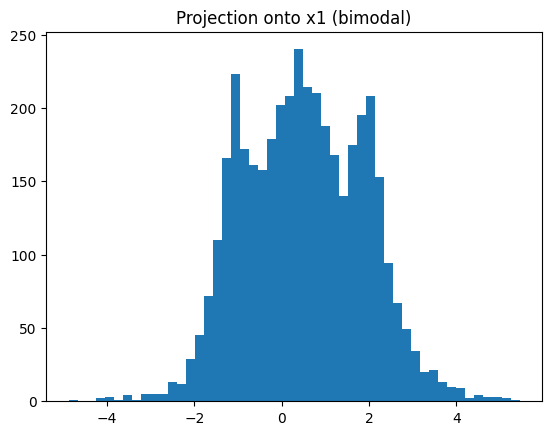

In [21]:
plt.hist(x_gen[:,0].numpy(), bins=50)
plt.title("Projection onto x1 (bimodal)")
plt.show()
